# 12f — Climate Risk Index and IPCC Hazard-Impact Tables

A Global Climate Risk Index-style breakdown of fatalities, people
affected, and economic losses by hazard type, and IPCC AR6 Interactive
Atlas-style regional climate-hazard indicator tables — the projected
change in 6 extreme-climate indicators (hottest day, coldest night, 1-day
and 5-day maximum precipitation, soil-moisture indices, consecutive dry
days) across 3 global-warming levels ($1.5°C$, $2.0°C$, $4.0°C$) for 50
world regions (IPCC AR6 reference regions plus Global/Ocean/Land
aggregates).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_yellow = "#bcbd22"
color_salmon = "#ff9896"
color_teal   = "#17becf"

plt.rcParams["figure.dpi"] = 100


## 1. Fatalities, affected population, and economic loss by hazard type

Global totals by hazard category (drought, flood, heat wave, storm,
wildfire, other), each shown as a share of the category total. Building
this table exposed a subtle index-alignment bug: passing the hazard
labels straight into the `DataFrame` constructor let pandas silently
realign the rows against the wrong index. It was fixed by building the
shares table first and attaching the hazard-name index afterward.


,Fatalities,Affected,Economic loss
Drought,3.0,32.0,6.4
Flood,24.7,47.8,29.1
Heat wave,33.4,0.6,0.7
Storm,33.0,17.4,58.4
Wildfire,0.3,0.3,3.9
Other,5.5,2.0,1.4


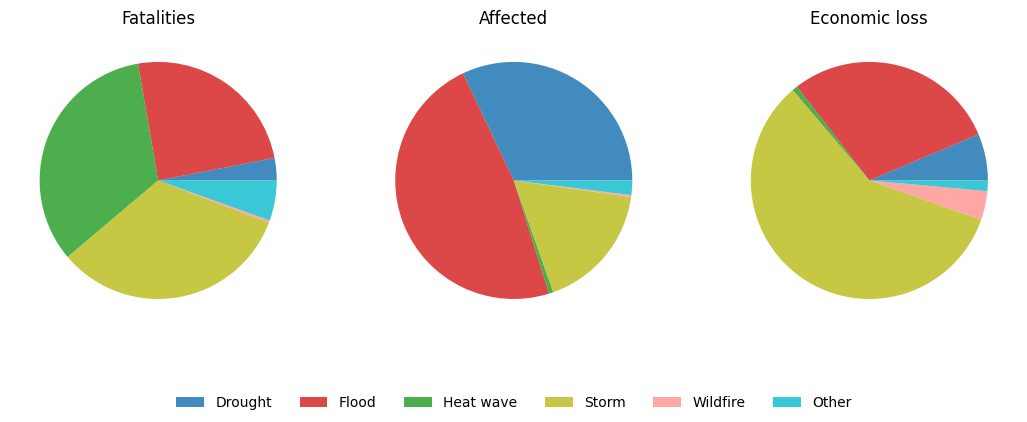

In [2]:
cri = pd.read_excel(f"{DATA_DIR}/chap12_ext_cri_2026.xlsx", sheet_name="Table 2")
labels = cri["Hazard"]
colors = [color_blue, color_red, color_green, color_yellow, color_salmon, color_teal]

shares = pd.DataFrame({
    "Fatalities": cri["Fatalities"] / cri["Fatalities"].sum(),
    "Affected": cri["Affected"] / cri["Affected"].sum(),
    "Economic loss": cri["Economic_loss_USD"] / cri["Economic_loss_USD"].sum(),
})
# Assign the hazard-name index after construction (not via the constructor's
# `index=` argument) to avoid a silent alignment mismatch between labels and rows.
shares.index = labels.values
display((100 * shares).round(1))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, shares.columns):
    ax.pie(shares[col], colors=colors, wedgeprops=dict(alpha=0.85, edgecolor="none"))
    ax.set_title(col, fontsize=12)
fig.legend(labels, loc="lower center", ncol=6, fontsize=10, frameon=False)
fig.subplots_adjust(bottom=0.18)
plt.show()


## Shared data: IPCC AR6 regional hazard-indicator table

7 indicators (`TXx`, `TNn`, `Rx1day`, `Rx5day`, `Moisture`, `Moisture10`,
`CDD`), each read from its own sheet (`SM2`-`SM8`) at 3 global-warming
levels, with `Rx1day`/`Rx5day` rescaled ×100 (stored as fractions,
converted to percent) and a `-99` missing-data sentinel replaced with
`NaN`. Every sheet's `Region` column is checked for consistent ordering
across all 7 sheets before combining.


In [3]:
INDICATORS = ["TXx", "TNn", "Rx1day", "Rx5day", "Moisture", "Moisture10", "CDD"]
GWLS = ["GWL_15", "GWL_20", "GWL_40"]

region = None
blocks = []
for i, ind in enumerate(INDICATORS, start=1):
    sheet = f"SM{i+1}"
    T = pd.read_excel(f"{DATA_DIR}/chap12_ext_ipcc_hazard_impact.xlsx", sheet_name=sheet)
    if region is None:
        region = T["Region"]
    else:
        assert (T["Region"].values == region.values).all(), f"region mismatch in {sheet}"
    vals = T[GWLS].values.astype(float)
    if ind in ("Rx1day", "Rx5day"):
        vals = 100 * vals
    blocks.append(vals)

data = np.hstack(blocks)  # 50 regions x 21 (7 indicators x 3 GWLs)
data[data == -99] = np.nan
col_names = pd.MultiIndex.from_product([INDICATORS, ["1.5C", "2.0C", "4.0C"]])
hazard_table = pd.DataFrame(data, index=region.values, columns=col_names)
print(f"{hazard_table.shape[0]} regions x {hazard_table.shape[1]} (indicator, GWL) columns")


50 regions x 21 (indicator, GWL) columns


## 2. Regional hazard-indicator table, reordered and filtered

The full table (`TXx`, `TNn`, `Rx1day`, `Moisture`, `Moisture10`, `CDD` —
`Rx5day` dropped), with regions reordered so the three polar/ice regions
(Greenland/Iceland, East and West Antarctica) sit together at the end
rather than Greenland/Iceland appearing awkwardly right after the
Global/Ocean/Land aggregates.


In [4]:
KEEP_INDICATORS = ["TXx", "TNn", "Rx1day", "Moisture", "Moisture10", "CDD"]

# Reorder: rows 1-4, then 6-48, then 5, 49, 50 (1-based) -- moves
# Greenland/Iceland (row 5) to just before the two Antarctica rows.
order = list(range(0, 4)) + list(range(5, 48)) + [4, 48, 49]
reordered = hazard_table.iloc[order][KEEP_INDICATORS]
display(reordered.round(2))


TXx               TNn               \
                                          1.5C  2.0C  4.0C  1.5C  2.0C   4.0C   
Global (global)                           1.40  1.90  3.93  1.99  2.63   5.19   
Ocean (ocean)                             1.22  1.64  3.40  1.74  2.28   4.53   
Land (land)                               1.88  2.55  5.25  2.64  3.48   6.80   
Land w/o Antarctica (land_wo_antarctica)  1.94  2.65  5.47  2.73  3.59   7.05   
North-Western North America (NWN)         1.93  2.55  5.23  4.46  6.01  12.38   
North-Eastern North America (NEN)         2.22  2.99  5.96  4.85  6.37  13.22   
Western North America (WNA)               2.24  3.01  5.95  2.80  3.92   7.80   
Central North America (CNA)               2.33  3.12  5.71  2.54  3.76   7.82   
Eastern North America (ENA)               1.97  2.72  5.68  3.67  4.99   9.72   
Northern Central America (NCA)            1.81  2.45  4.84  1.79  2.36   5.03   
Southern Central America (SCA)            1.77  2.32  4.76  1.59  2.08   3.87   
Caribbean (CAR)                           1.59  2.11  4.33  1.51  2.02   3.74   
North-Western South America (NWS)         1.87  2.52  5.41  1.87  2.43   4.89   
Northern South America (NSA)              2.24  2.98  6.35  1.81  2.36   4.62   
North-Eastern South America (NES)         2.04  2.69  5.39  1.79  2.35   4.40   
South American Monsoon (SAM)              2.58  3.44  7.33  1.78  2.41   4.79   
South-Western South America (SWS)         1.91  2.50  4.83  2.04  2.66   5.90   
South-Eastern South America (SES)         1.95  2.57  5.45  1.42  1.80   3.75   
Southern South America (SSA)              1.91  2.41  4.52  2.14  2.79   6.40   
Northern Europe (NEU)                     1.81  2.54  4.99  5.08  6.46  10.59   
Western and Central Europe (WCE)          2.33  3.20  6.23  4.80  6.06  11.04   
Eastern Europe (EEU)                      2.20  2.97  5.76  4.90  6.16  11.33   
Mediterranean (MED)                       2.50  3.30  6.61  2.20  2.79   5.28   
Sahara (SAH)                              2.39  3.09  6.03  2.15  2.74   5.35   
Western Africa (WAF)                      1.62  2.19  4.53  2.04  2.65   4.63   
Central Africa (CAF)                      1.56  2.12  4.67  1.89  2.52   4.94   
North Eastern Africa (NEAF)               1.66  2.24  4.45  1.95  2.51   4.90   
South Eastern Africa (SEAF)               1.59  2.08  4.24  1.83  2.36   4.54   
West Southern Africa (WSAF)               2.03  2.73  5.29  1.77  2.40   4.75   
East Southern Africa (ESAF)               1.93  2.66  5.45  1.78  2.28   4.42   
Madagascar (MDG)                          1.63  2.17  4.65  1.63  2.08   3.93   
Russian Arctic (RAR)                      1.99  2.77  5.52  4.81  6.44  12.78   
West Siberia (WSB)                        2.11  2.80  5.09  4.05  5.52  10.26   
East Siberia (ESB)                        2.09  2.87  5.97  3.42  4.55   8.62   
Russian Far East (RFE)                    1.93  2.69  5.45  4.10  5.56  11.17   
West Central Asia (WCA)                   2.34  3.08  6.09  2.75  3.56   7.32   
East Central Asia (ECA)                   2.17  2.92  5.70  2.26  2.97   5.77   
Tibetan Plateau (TIB)                     1.65  2.32  4.55  2.42  2.97   5.74   
East Asia (EAS)                           1.50  2.19  4.66  2.11  2.95   5.83   
Arabian Peninsula (ARP)                   2.29  3.06  5.99  2.30  2.84   5.96   
South Asia (SAS)                          1.20  1.81  4.12  1.79  2.48   5.23   
South East Asia (SEA)                     1.40  1.85  4.23  1.46  1.96   4.10   
Northern Australia (NAU)                  1.59  2.03  3.99  1.97  2.57   5.08   
Central Australia (CAU)                   1.95  2.53  4.85  1.62  2.06   4.22   
Eastern Australia (EAU)                   1.60  2.13  4.25  1.37  1.89   3.76   
Southern Australia (SAU)                  1.71  2.30  4.48  1.10  1.52   2.95   
New Zealand (NZ)                          1.36  1.82  3.68  1.33  1.74   3.41   
Greenland/Iceland (GIC)                   1.21  1.54  2.97  3.88  4.99   9

## 3. Top-5 most-affected regions per indicator at $+4.0°C$

For each indicator (excluding `Rx5day`, and excluding the 4 aggregate
rows — Global/Ocean/Land/Land-w/o-Antarctica — so only the 46 individual
IPCC reference regions are ranked), the 5 regions with the most extreme
projected change at the highest warming level ($+4.0°C$). Ranked by
*largest decrease* for the two soil-moisture indicators (drying is the
hazard direction there) and by *largest increase* for the rest.


In [5]:
regional_only = hazard_table.iloc[4:]  # drop the 4 aggregate rows (Global/Ocean/Land/Land w/o Antarctica)

top5 = {}
for ind in KEEP_INDICATORS:
    col = regional_only[(ind, "4.0C")]
    ascending = ind in ("Moisture", "Moisture10")
    ranked = col.sort_values(ascending=ascending, na_position="last").head(5)
    top5[ind] = pd.DataFrame({"Region": ranked.index, ind: ranked.values})

for ind in KEEP_INDICATORS:
    print(f"Top 5 regions, {ind} at +4.0C GWL:")
    display(top5[ind].round(2))


Top 5 regions, TXx at +4.0C GWL:


,Region,TXx
0,South American Monsoon (SAM),7.33
1,Mediterranean (MED),6.61
2,Northern South America (NSA),6.35
3,Western and Central Europe (WCE),6.23
4,West Central Asia (WCA),6.09


Top 5 regions, TNn at +4.0C GWL:


,Region,TNn
0,North-Eastern North America (NEN),13.22
1,Russian Arctic (RAR),12.78
2,North-Western North America (NWN),12.38
3,Eastern Europe (EEU),11.33
4,Russian Far East (RFE),11.17


Top 5 regions, Rx1day at +4.0C GWL:


...

,Region,Moisture
0,South-Western South America (SWS),-4.83
1,Mediterranean (MED),-4.18
2,South American Monsoon (SAM),-3.81
3,North-Western South America (NWS),-3.50
4,Southern Central America (SCA),-3.42


Top 5 regions, Moisture10 at +4.0C GWL:


,Region,Moisture10
0,Northern Europe (NEU),-3.79
1,Mediterranean (MED),-3.62
2,Southern Central America (SCA),-3.43
3,South American Monsoon (SAM),-3.36
4,North-Western South America (NWS),-3.22


Top 5 regions, CDD at +4.0C GWL:


,Region,CDD
0,West Southern Africa (WSAF),28.84
1,North-Eastern South America (NES),28.44
2,East Southern Africa (ESAF),23.51
3,Northern South America (NSA),19.56
4,South American Monsoon (SAM),19.05
